# Verifying Published Results

This notebook reproduces the results of the experiments reported in published papers to verify that the `pdfa_learning` package produces the same results. The experiments are based on the following papers:
- [Learning stochastic regular grammars by means of a state merging method](https://doi.org/10.1007/3-540-58473-0_144) by Carrasco and Oncina (1994) [1]
- [Improving hospital layout planning through clinical pathway mining](10.1007/s10479-017-2485-4) by Arnolds and Gartner (2018) [2]
- [Using Finite State Automata for Sequence Mining](10.5555/563801.563814) by Hingston (2002) [3]

## Notebook Set Up

In [1]:
from pathlib import Path
import sys

repository_root = Path.cwd().parents[1]

if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

import pdfa_learning as pl

## 1. Carrasco and Oncina (1994) [1]

We can verify the results of the example provided in the paper by Carrasco and Oncina (1994) [1].

The authors provide a set of sequences, and return a learned PDFA first for an `alpha` value of 0.8. 

In [18]:
carrasco_sequences = [
    "110",
    "",
    "",
    "",
    "0",
    "",
    "00",
    "00",
    "",
    "",
    "",
    "10110",
    "",
    "",
    "100",
]

carrasco_alphabet = pl.get_alphabet(carrasco_sequences)
carrasco_states = pl.get_initial_states(carrasco_sequences)
carrasco_matrix = pl.get_transition_matrix(
    carrasco_sequences, 
    carrasco_alphabet,
)

(
    carrasco_final_matrix, 
    carrasco_final_states, 
    carrasco_final_merges
) = pl.alergia(
    carrasco_matrix, 
    carrasco_states, 
    carrasco_alphabet, 
    0.8,
)

Below is the learned PDFA, which matches that of Figure 13 in the paper.

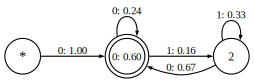

In [6]:
carrasco_pdfa = pl.network_visualisation(
    carrasco_final_matrix, 
    carrasco_final_states, 
    carrasco_alphabet,
    filename="carrasco_pdfa",
    save=False,
    probabilities=True,
    graph_format="pdf",
)

carrasco_pdfa

For further verification, we can also set the `output_level` parameter to `Truncated` to see a partial output of the `alergia` algorithm, since the authors provide a description of the merging process in the Appendix of the paper.

In [21]:
(
    carrasco_final_matrix, 
    carrasco_final_states, 
    carrasco_final_merges
) = pl.alergia(
    carrasco_matrix, 
    carrasco_states, 
    carrasco_alphabet, 
    0.8,
    output_level="Truncated",
)

The next pair of states to check is: (1, 0)
Hoeffding Bound satisfied for (1, 0)
Recursively merged states. Successfully merged (1, 0)
The next pair of states to check is: (2, 0)
Hoeffding Bound not satisfied for (2, 0)
The next pair of states to check is: (4, 0)
Hoeffding Bound satisfied for (4, 0)
Recursively merged states. Successfully merged (4, 0)
The next pair of states to check is: (2, 0)
Hoeffding Bound not satisfied for (2, 0)
The next pair of states to check is: (5, 0)
Hoeffding Bound not satisfied for (5, 0)
The next pair of states to check is: (5, 2)
Hoeffding Bound satisfied for (5, 2)
Recursively merged states. Successfully merged (5, 2)
The next pair of states to check is: (2, 0)
Hoeffding Bound not satisfied for (2, 0)


## 2. Arnolds and Gartner (2018) [2]

We can verify the results of two examples provided in the paper by Arnolds and Gartner (2018) [2].

The authors provide a set of sequences, and return a learned PDFA first for an `alpha` value of 0.2, and then for an `alpha` value of 0.8. 

Note the authors of this paper use the red-blue framework for state merging, so the `method` parameter is set to `de_la_higuera` in the `alergia` function.

In [13]:
arnolds_sequences = [
    "AB", 
    "ABA", 
    "ABB", 
    "ABCA", 
    "AC", 
    "ACC", 
    "BA", 
    "BAA", 
    "BC", 
    "BCA",
]

arnolds_alphabet = pl.get_alphabet(arnolds_sequences)
arnolds_states = pl.get_initial_states(arnolds_sequences)
arnolds_matrix = pl.get_transition_matrix(
    arnolds_sequences, 
    arnolds_alphabet,
)

(
    arnolds_final_matrix_point2, 
    arnolds_final_states_point2, 
    arnolds_final_merges_point2,
) = pl.alergia(
    arnolds_matrix, 
    arnolds_states, 
    arnolds_alphabet, 
    0.2,
    method="de_la_higuera",
)

(
    arnolds_final_matrix_point8, 
    arnolds_final_states_point8, 
    arnolds_final_merges_point8,
) = pl.alergia(
    arnolds_matrix, 
    arnolds_states, 
    arnolds_alphabet, 
    0.8, 
    method="de_la_higuera",
)

Below is the learned PDFA for an `alpha` value of 0.2, which matches that of Figure 4 in the paper.

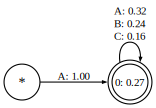

In [14]:
arnolds_pdfa_point2 = pl.network_visualisation(
    arnolds_final_matrix_point2,
    arnolds_final_states_point2,
    arnolds_alphabet,
    filename="arnolds_pdfa_point2",
    save=False,
    probabilities=True,
    graph_format="pdf",
)

arnolds_pdfa_point2

Below is the learned PDFA for an `alpha` value of 0.8, which matches that of Figure 4 in the paper.

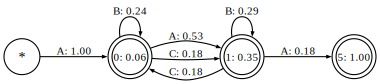

In [15]:
arnolds_pdfa_point8 = pl.network_visualisation(
    arnolds_final_matrix_point8,
    arnolds_final_states_point8,
    arnolds_alphabet,
    filename="arnolds_pdfa_point8",
    save=False,
    probabilities=True,
    graph_format="pdf",
)

arnolds_pdfa_point8

For further verification, we can also set the `output_level` parameter to `Full` to see the full output of the `alergia` function for the `alpha` value of 0.2, since the authors provide the full output in Section 4.2 of the paper.

In [17]:
(
    arnolds_final_matrix_point2, 
    arnolds_final_states_point2, 
    arnolds_final_merges_point2,
) = pl.alergia(
    arnolds_matrix, 
    arnolds_states, 
    arnolds_alphabet, 
    0.2,
    output_level="Full",
    method="de_la_higuera"
)

Iteration 1
Hoeffding Bound satisfied for (0, 1)
Merging of states (0, 1) results in non-deterministic pairs: [(2, 3)]
Successfully merged states (2, 3) into a deterministic state.
Merging of previous non-deterministic pair results in non-deterministic pairs: [(5, 10), (7, 11)]
Successfully merged states (5, 10) into a deterministic state.
Merging of previous non-deterministic pair results in non-deterministic pairs: [(7, 11)]
Successfully merged states (7, 11) into a deterministic state.
Merging of previous non-deterministic pair results in non-deterministic pairs: [(8, 13)]
Successfully merged states (8, 13) into a deterministic state.
Recursively merged states. Successfully merged (0, 1)
Iteration 2
Hoeffding Bound satisfied for (0, 2)
Merging of states (0, 2) results in non-deterministic pairs: [(0, 5), (0, 6), (4, 7)]
Successfully merged states (0, 5) into a deterministic state.
Merging of previous non-deterministic pair results in non-deterministic pairs: [(0, 12), (0, 6), (4, 7)

## 3. Hingston (2002) [4]

We can verify the results of the example provided in the paper by Hingston (2002) [4].

This paper differs from the others in that it introduces many of the probability measures used in the `pdfa_learning` package. Using their defined PDFA, we can verify that the probability measures are calculated correctly.

In [22]:
import numpy as np

hingston_matrix = np.array(
    [
        [
            [0, 1.0, 0, 0],
            [0, 0, 0, 0.314],
            [0, 0.532, 0, 0],
            [0, 0, 0.54, 0],
        ],
        [
            [0, 0, 0, 0],
            [0, 0, 0.348, 0],
            [0, 0, 0, 0.468],
            [0, 0.46, 0, 0],
        ],
    ]
)

hingston_alphabet = ["a", "b"]

We can recreate the main result in Section 4 of the paper, which is the probability estimate of the symbol "a" in the PDFA defined by the authors. 

In [25]:
pl.probability_estimate_of_symbol(hingston_matrix, "a", hingston_alphabet)

array([1.        , 0.63462721, 0.92134254, 0.83192851])

For further clarity, we can also show the intermediate steps of the calculation, which are described in Section 4 of the paper.

In [27]:
p_mat = hingston_matrix

p_mat = np.delete(p_mat, 0, axis=1)
p_mat = np.delete(p_mat, 0, axis=2)

matrix_index = hingston_alphabet.index("a")

rho = np.sum(np.delete(p_mat, matrix_index, 0), axis=0)

inverse = np.linalg.inv(np.identity(p_mat.shape[1]) - rho)

p_symbol = np.sum(p_mat[matrix_index, :, :], axis=1)
p_mat

array([[[0.   , 0.   , 0.314],
        [0.532, 0.   , 0.   ],
        [0.   , 0.54 , 0.   ]],

       [[0.   , 0.348, 0.   ],
        [0.   , 0.   , 0.468],
        [0.46 , 0.   , 0.   ]]])

## References

[1] Carrasco, R. C. and Oncina, J. (1994). "Learning Stochastic Regular Grammars by Means of a State Merging Method." In *Grammatical Inference and Applications*, pp. 139–152.

[2] Arnolds, I.V. and Gartner, D., (2018). Improving hospital layout planning through clinical pathway mining. Annals of operations research, 263(1), pp.453-477.

[3] Hingston, P. (2002). Using finite state automata for sequence mining. In ACSC (pp. 105-110).